# Imports

In [1]:
# Usual stuff
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Path
from pathlib import Path

# Plots

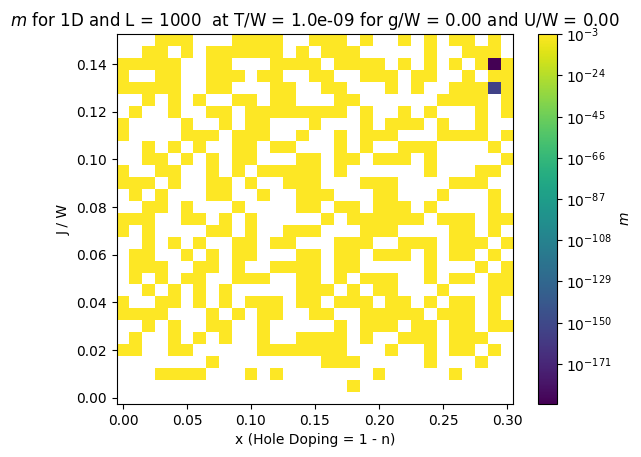

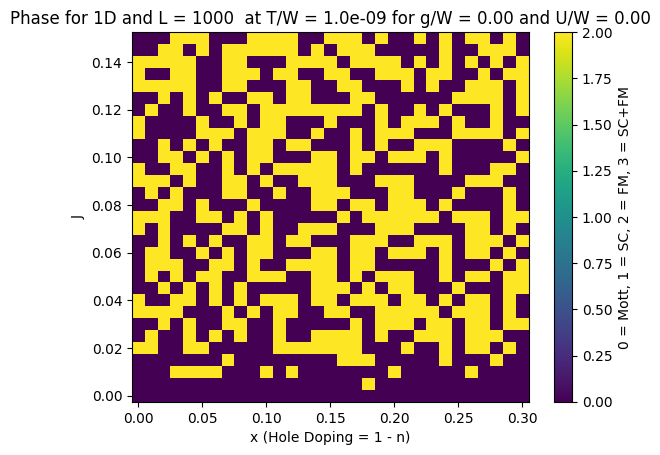

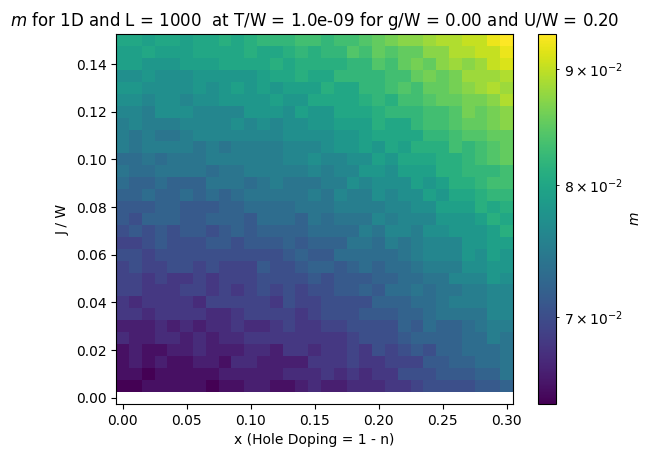

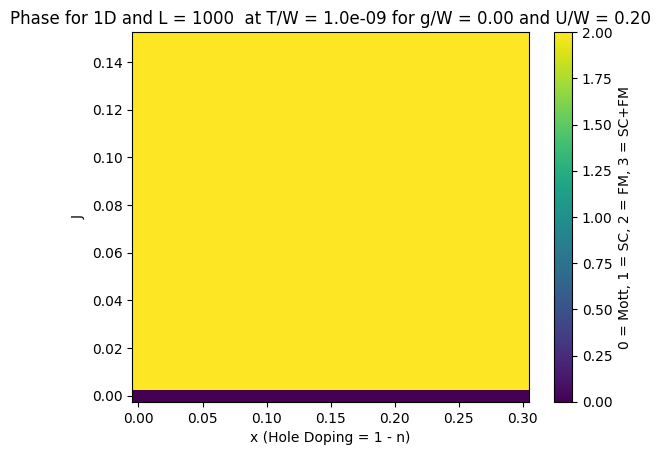

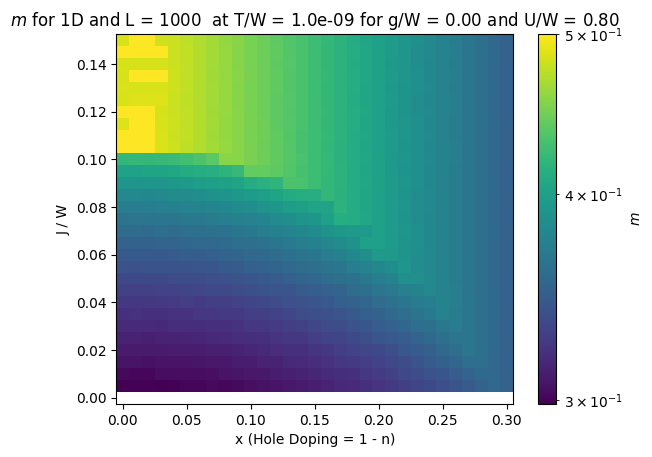

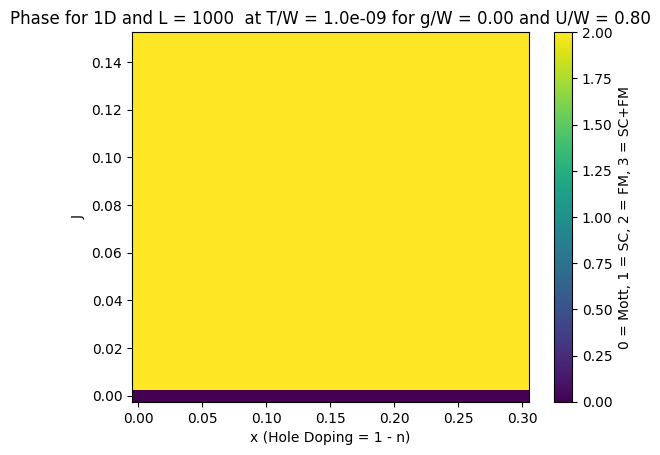

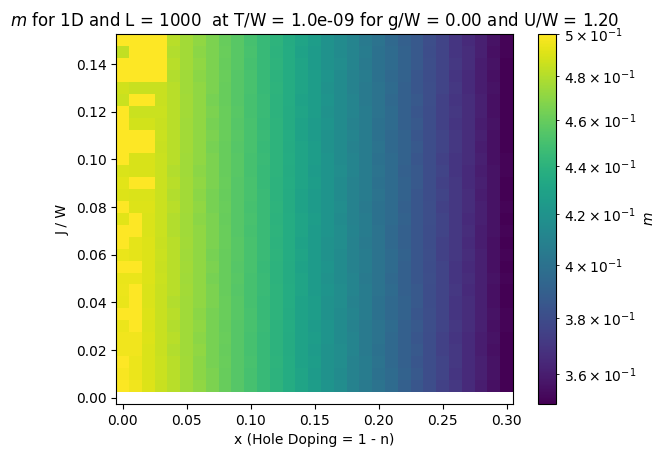

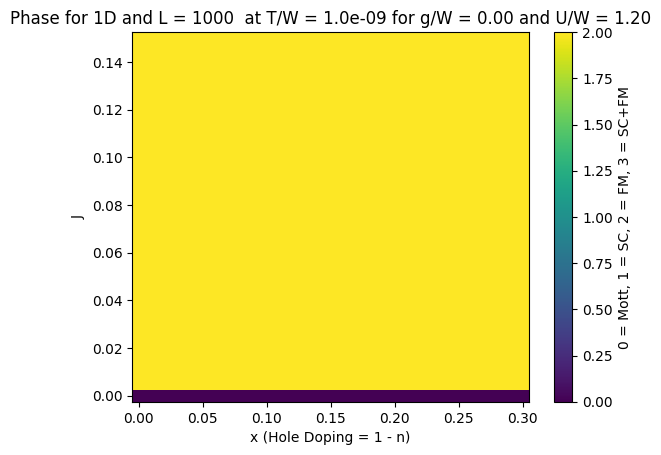

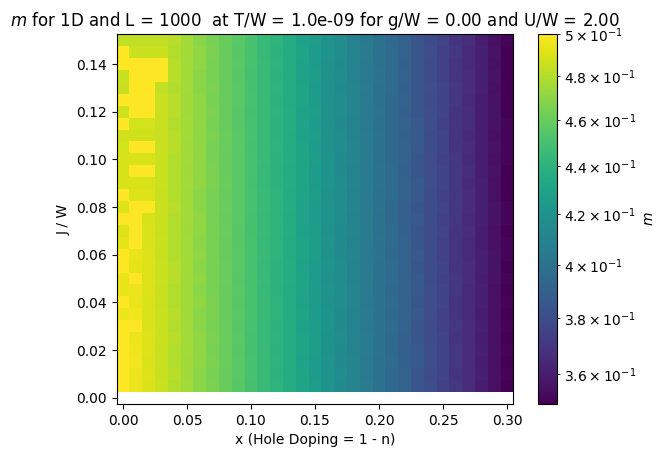

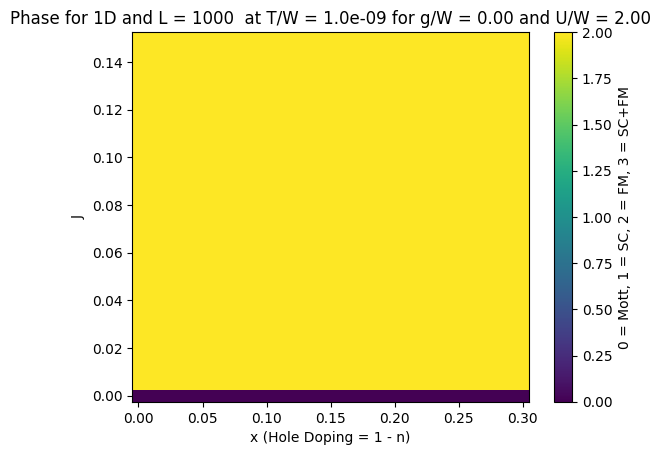

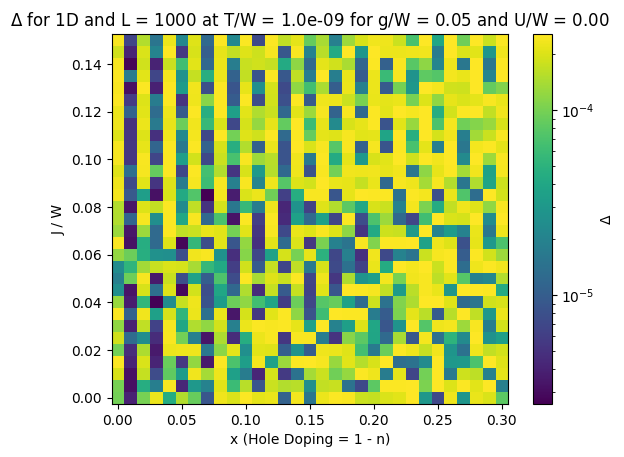

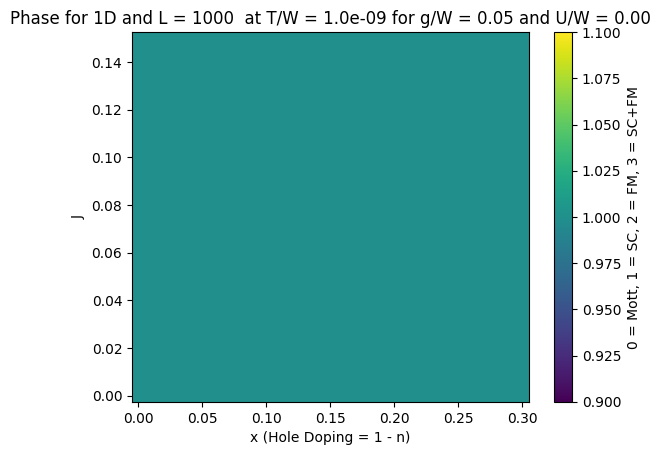

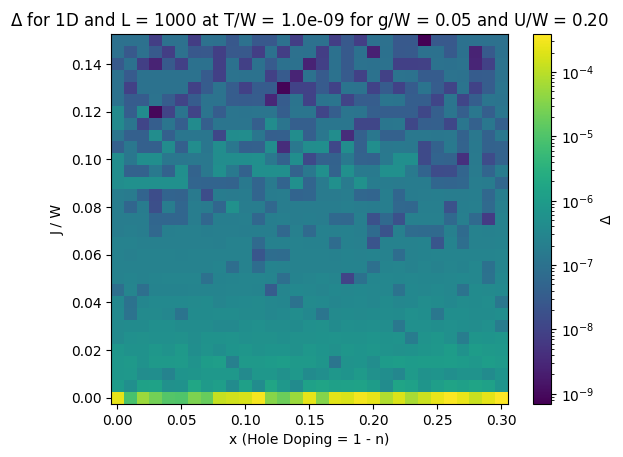

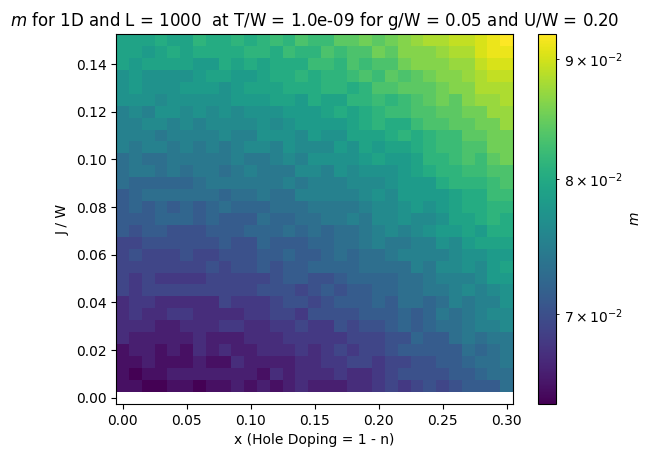

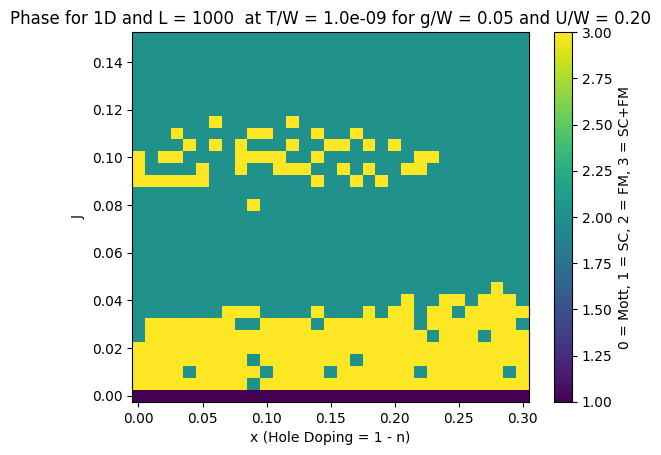

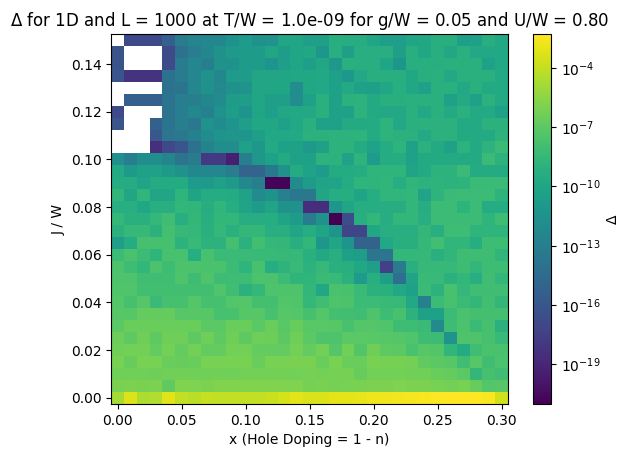

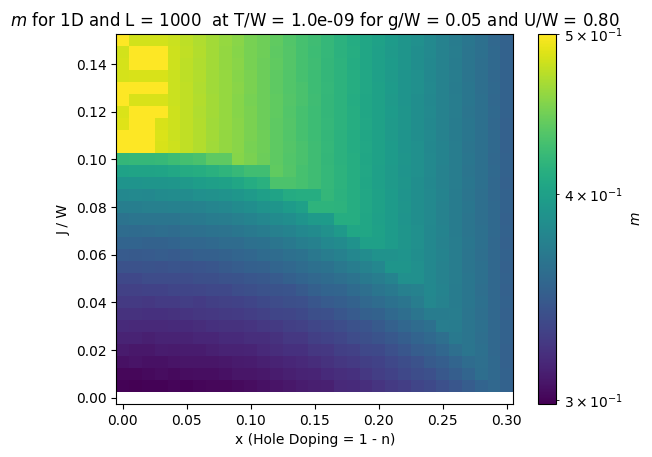

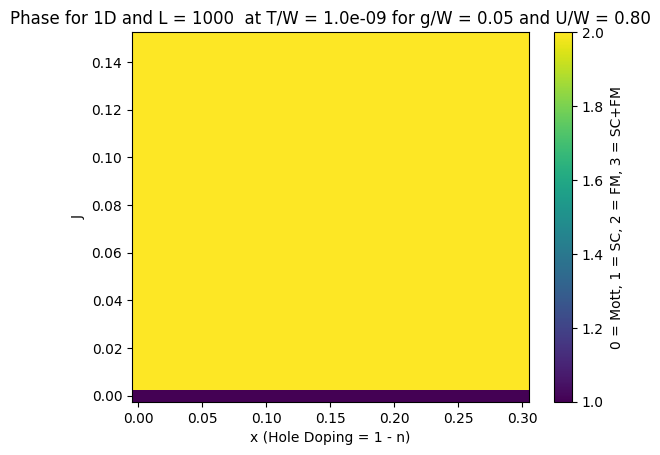

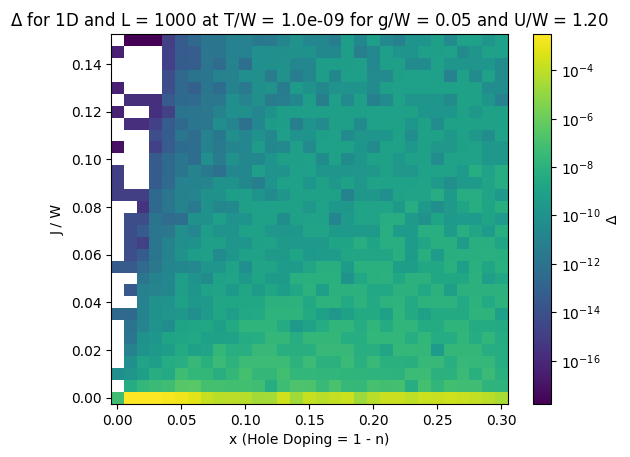

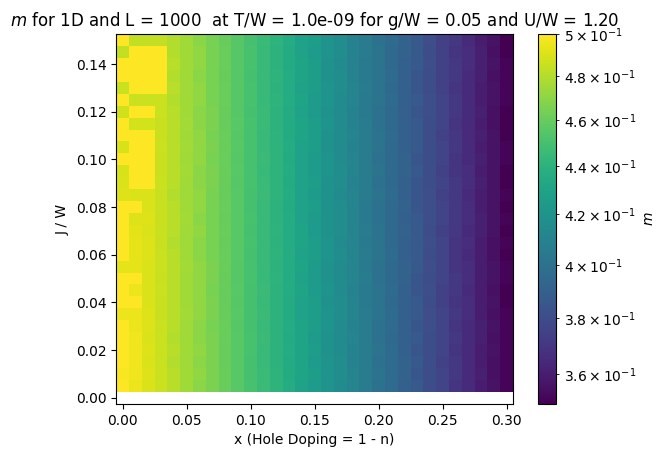

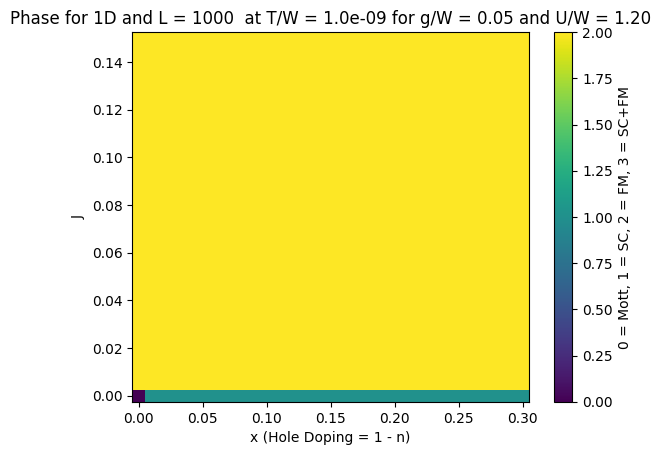

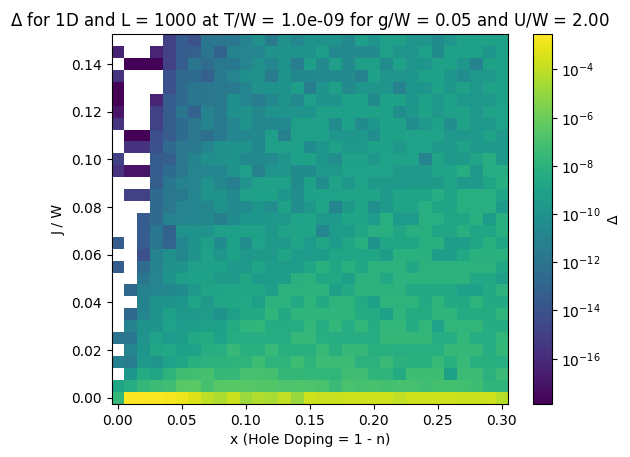

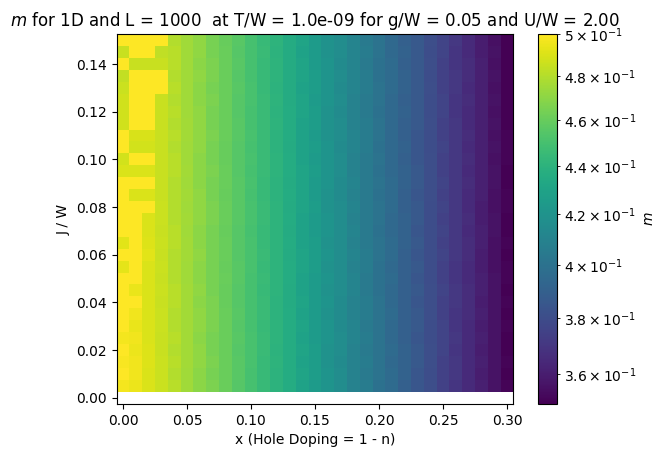

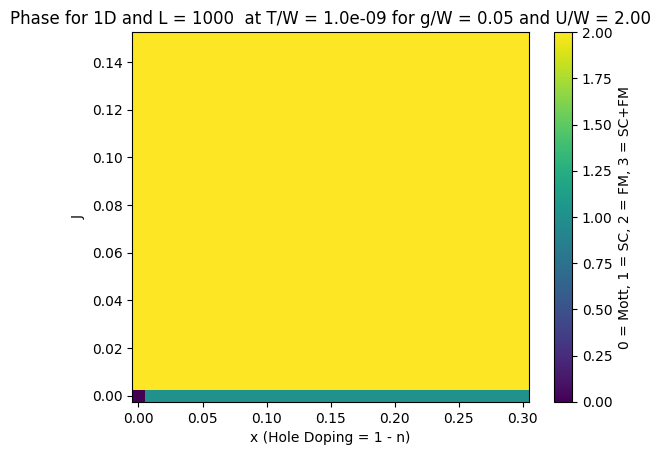

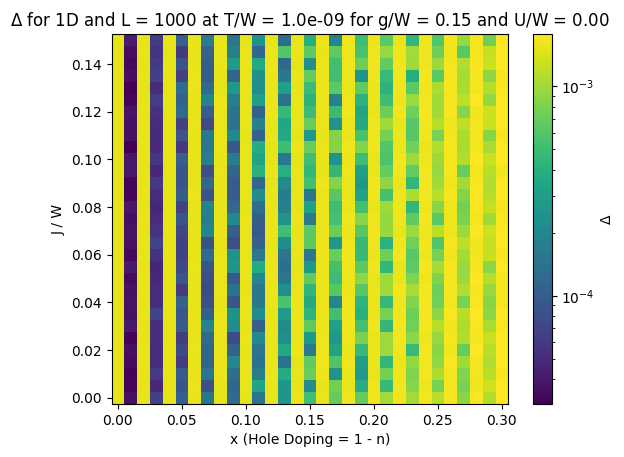

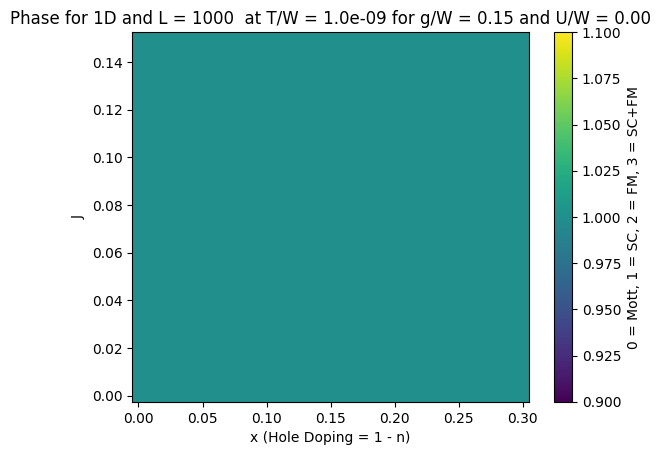

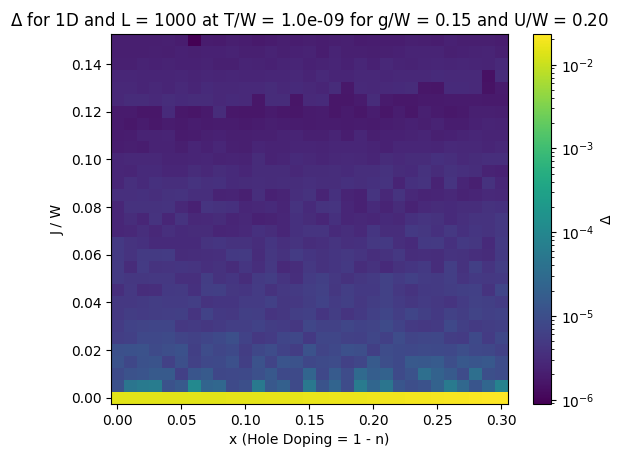

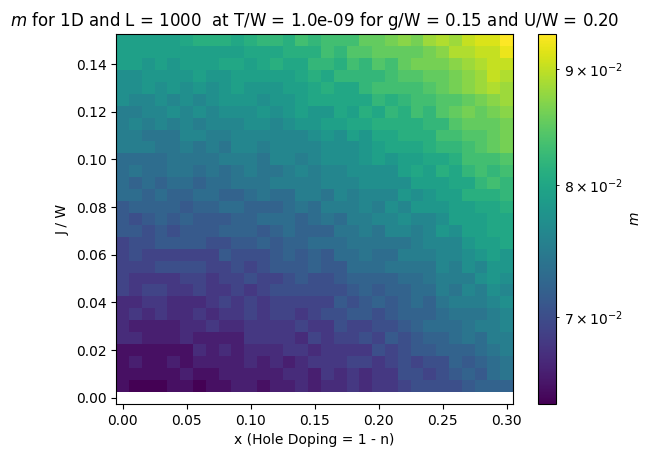

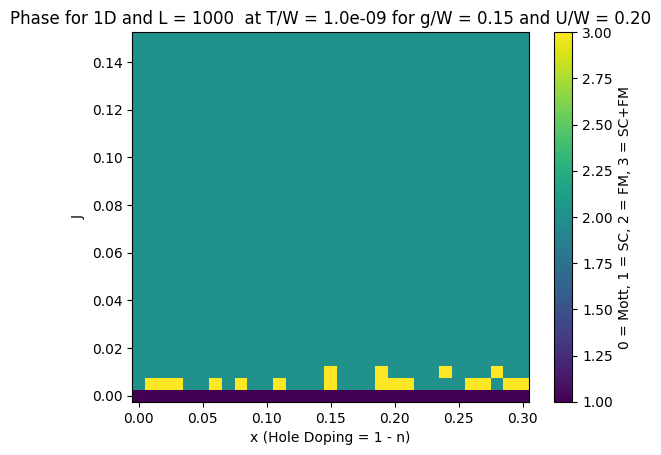

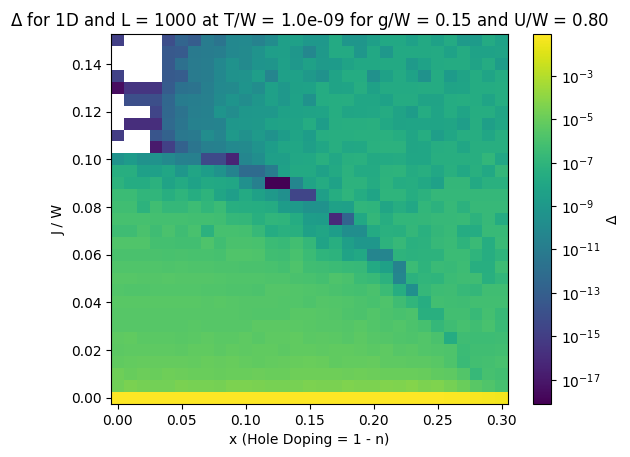

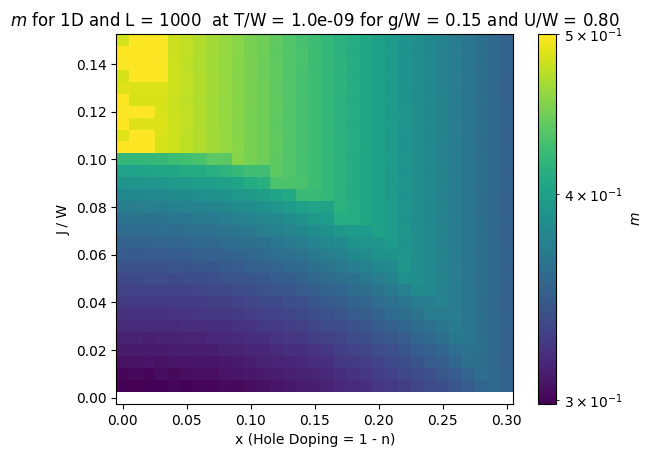

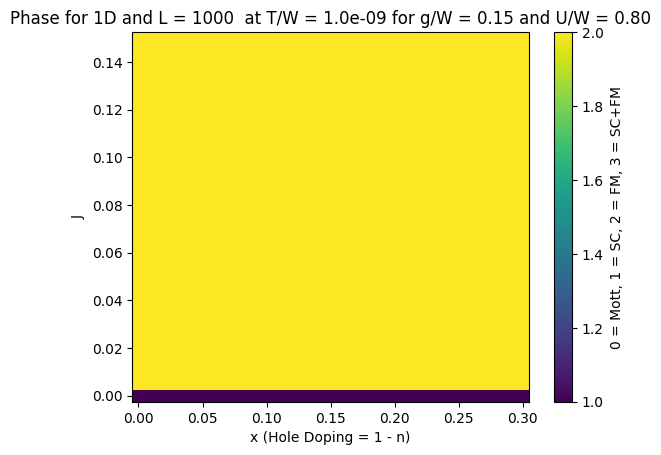

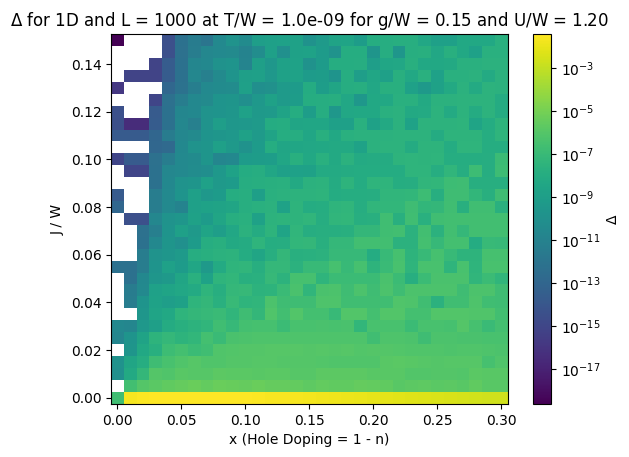

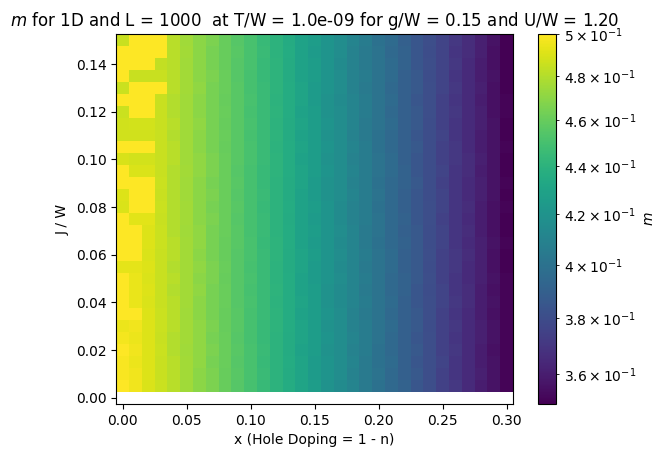

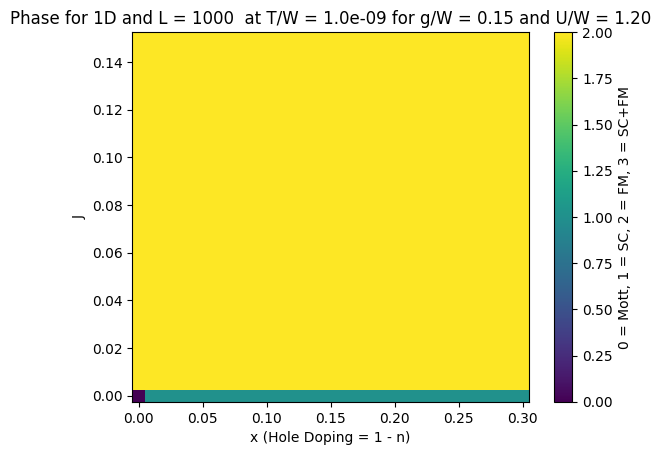

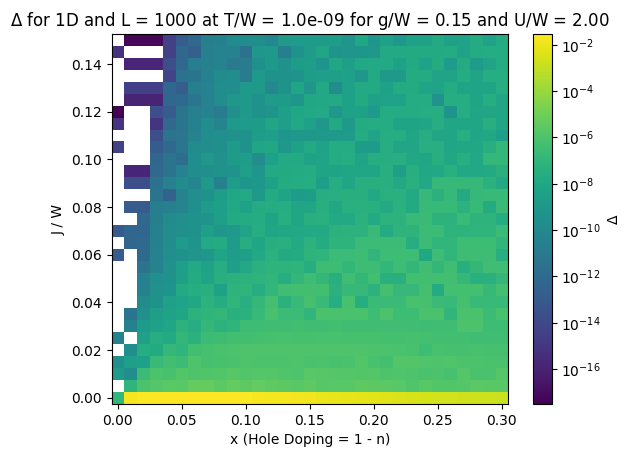

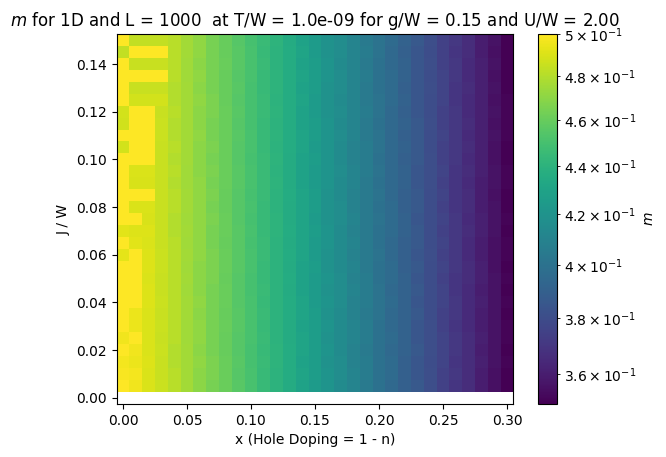

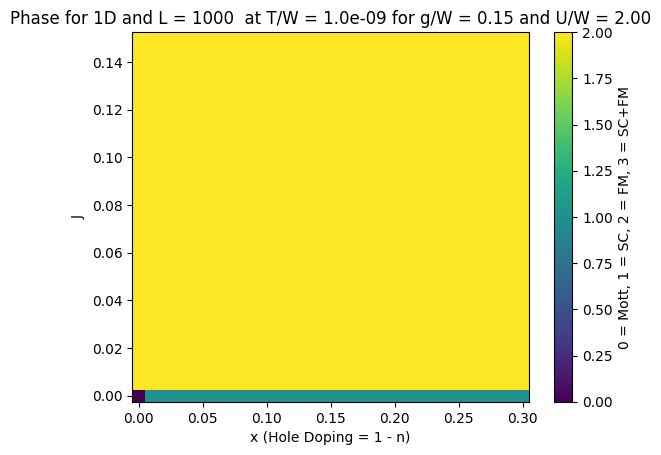

In [2]:
# Get the directory where the script is located
current_dir = Path.cwd()

# Get the output directory
current_out = current_dir / "outputs"

# Iterate through all items in the folder
for file in current_out.iterdir():
    if file.is_file():
        if str(file.suffix) == ".npz":
            # Get the data
            data = np.load(current_out / file.name)
            xx_mesh, jj_mesh, dd_mesh, mm_mesh = data["xx_mesh"], data["jj_mesh"], data["dd_mesh"], data["mm_mesh"]
            
            # Get the parameters
            d, L, T, g, U = file.stem.split("=")
            d, L, T, g, U = int(d), int(L), float(T), float(g), float(U)
            W = 4 * d

            # Treshold of the maximum value
            delta_zero_mult = 1e-3
            m_zero_mult = 1e-3

            # Set zeros to a fraction of the maximum value
            delta_zero = delta_zero_mult * np.max(dd_mesh)
            m_zero = m_zero_mult * np.max(mm_mesh)

            # Make the phase diagram
            pp_mesh = np.zeros_like(jj_mesh)
            pp_mesh += 1 * (dd_mesh > delta_zero)
            pp_mesh += 2 * (mm_mesh > m_zero)

            if np.max(dd_mesh) != 0:
                plt.title(f"$\\Delta$ for {d}D and L = {L} at T/W = {T/W:.1e} for g/W = {g/W:.2f} and U/W = {U/W:.2f}")
                plt.pcolormesh(xx_mesh, jj_mesh / W, dd_mesh, cmap="viridis", norm=colors.LogNorm(vmin=np.min(dd_mesh[dd_mesh > 0]), vmax=np.max(dd_mesh)))
                plt.colorbar(label="$\\Delta$")
                plt.xlabel("x (Hole Doping = 1 - n)")
                plt.ylabel("J / W")
                plt.show()

            if np.max(mm_mesh) != 0:
                plt.title(f"$m$ for {d}D and L = {L}  at T/W = {T/W:.1e} for g/W = {g/W:.2f} and U/W = {U/W:.2f}")
                plt.pcolormesh(xx_mesh, jj_mesh / W, mm_mesh, cmap="viridis", norm=colors.LogNorm(vmin=np.min(mm_mesh[mm_mesh > 0]), vmax=np.max(mm_mesh)))
                plt.colorbar(label="$m$")
                plt.xlabel("x (Hole Doping = 1 - n)")
                plt.ylabel("J / W")
                plt.show()

            plt.title(f"Phase for {d}D and L = {L}  at T/W = {T/W:.1e} for g/W = {g/W:.2f} and U/W = {U/W:.2f}")
            plt.pcolormesh(xx_mesh, jj_mesh / W, pp_mesh, cmap="viridis")
            plt.colorbar(label="0 = Mott, 1 = SC, 2 = FM, 3 = SC+FM")
            plt.xlabel("x (Hole Doping = 1 - n)")
            plt.ylabel("J")
            plt.show()